In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples, pairwise_distances
from joblib import Parallel, delayed
import plotly.graph_objects as go
import plotly.express as px
import ast
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
import debugpy
from itertools import combinations
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Load Preprocessed Data & Feature Selection

In [3]:
# Run preprocessing to regenerate X and y with a real filename so breakpoints in preprocessing.py work
with open('preprocessing.py', 'r', encoding='utf-8') as f:
    exec(compile(f.read(), 'preprocessing.py', 'exec'), globals())

print(f"\nData loaded successfully!")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns:\n{list(X.columns)}")

Loading data...
<class 'pandas.DataFrame'>
RangeIndex: 47346 entries, 0 to 47345
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          47346 non-null  int64  
 1   is_confirmed                47346 non-null  int64  
 2   is_payment_verified         47346 non-null  int64  
 3   is_fulfilled                47346 non-null  int64  
 4   state                       47346 non-null  str    
 5   registered_date             47346 non-null  str    
 6   date_from                   47346 non-null  str    
 7   date_to                     47346 non-null  str    
 8   adult_count                 47346 non-null  int64  
 9   child_count                 47346 non-null  int64  
 10  infant_count                47346 non-null  int64  
 11  travel_type                 3 non-null      str    
 12  price                       47346 non-null  int64  
 13  discount                  

In [4]:
# Select mixed-type features for clustering with Gower distance
clustering_features = [
    'lead_time_days', 'stay_nights', 'booking_month', 'booking_dow','sum_room_children', 'sum_room_extra_bed',
    'hotel_rank', 'hotel_stars', 
    'discount', 'final_price', 'is_b2b', 'book_from_recommendation', 'city_id', 'hotel_accommodation'
]


print('clustering_features', clustering_features);

X_cluster = X[clustering_features].copy()

cat_cols = [c for c in ['booking_month', 'booking_dow', 'city_id', 'is_b2b', 'book_from_recommendation', 'hotel_accommodation'] if c in X_cluster.columns]
numeric_cols = [c for c in X_cluster.select_dtypes(include=[np.number]).columns.tolist() if c not in cat_cols]

X_cluster_num = X_cluster[numeric_cols].copy()
X_cluster_cat = X_cluster[cat_cols].copy()


print('len(X_cluster)', len(X_cluster));
print(f"Clustering features selected: {len(clustering_features)}")
print(f"Clustering dataset shape: {X_cluster.shape}")
print(f"\nFeatures for clustering:\n{clustering_features}")
print(f"\nMissing values after imputation:\n{X_cluster.isnull().sum()}")




clustering_features ['lead_time_days', 'stay_nights', 'booking_month', 'booking_dow', 'sum_room_children', 'sum_room_extra_bed', 'hotel_rank', 'hotel_stars', 'discount', 'final_price', 'is_b2b', 'book_from_recommendation', 'city_id', 'hotel_accommodation']
len(X_cluster) 44358
Clustering features selected: 14
Clustering dataset shape: (44358, 14)

Features for clustering:
['lead_time_days', 'stay_nights', 'booking_month', 'booking_dow', 'sum_room_children', 'sum_room_extra_bed', 'hotel_rank', 'hotel_stars', 'discount', 'final_price', 'is_b2b', 'book_from_recommendation', 'city_id', 'hotel_accommodation']

Missing values after imputation:
lead_time_days              0
stay_nights                 0
booking_month               0
booking_dow                 0
sum_room_children           0
sum_room_extra_bed          0
hotel_rank                  0
hotel_stars                 0
discount                    0
final_price                 0
is_b2b                      0
book_from_recommendation

## Step 1: Feature selection for getting best score by Gower Distance Heiracical Clustering
For calculating faster use parallel task (for windows os) and store them as csv.

In [5]:
def gower_matrix(df, features):
    df = df.copy()
    numeric_features =[x for x in features if x in numeric_cols]
    categorical_features = [x for x in features if x in cat_cols]

    if len(numeric_features):
        X_num = df[numeric_features].astype(float).to_numpy()
        ranges = X_num.max(axis=0) - X_num.min(axis=0)
        ranges[ranges == 0] = 1
        X_num_scaled = X_num / ranges
        num_dists = pairwise_distances(X_num_scaled, metric='manhattan', n_jobs=-1) / X_num_scaled.shape[1]
    else:
        num_dists = np.zeros((len(df), len(df)))

    if len(categorical_features):
        # cat_matrix = np.column_stack([df[col].astype(str).to_numpy() for col in categorical_features])
        X_cat = df[categorical_features].astype(str).to_numpy()
        cat_dists = np.zeros((len(df), len(df)), dtype=float)
        for j in range(X_cat.shape[1]):
            cat_dists += (X_cat[:, None, j] != X_cat[None, :, j]).astype(float)
        cat_dists /= len(categorical_features)
    else:
        cat_dists = np.zeros((len(df), len(df)))

    if len(numeric_features) and len(categorical_features):
        return (num_dists * len(numeric_features) + cat_dists * len(categorical_features)) / (
            len(numeric_features) + len(categorical_features)
        )
    elif len(numeric_features):
        return num_dists
    else:
        return cat_dists

In [ ]:
# Search across feature combinations to find strong clustering subsets
max_combo_size = 5  
min_combo_size = 4
sample_size = min(1000, len(X_cluster))
cluster_range = range(2, 6)  

X_sample = X_cluster.sample(n=sample_size, random_state=100).reset_index(drop=True)


def score_subset(subset):
    # combo_cat_cols = [c for c in subset if c in cat_cols]
    dist = gower_matrix(X_sample[subset], features=subset)

    best_score = -np.inf
    best_k = None
    for cluster_count in cluster_range:
        labels = AgglomerativeClustering(n_clusters=cluster_count, metric='precomputed', linkage='average').fit_predict(dist)
        score = silhouette_score(dist, labels, metric='precomputed')
        if score > best_score:
            best_score = score
            best_k = cluster_count

    return best_score, best_k, subset

combo_args = [list(combo)
              for size in range(min_combo_size, max_combo_size + 1)
              for combo in combinations(clustering_features, size)]
print('combo_args', len(combo_args));

debug_mode = debugpy.is_client_connected()
print(f'Debug mode: {debug_mode}')

if debug_mode:
    combo_results = [score_subset(subset) for subset in combo_args]
else:
    combo_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(score_subset)(subset) for subset in combo_args
    )

combo_scores = sorted(combo_results, reverse=True, key=lambda x: x[0])
print(f"Top 10 combinations (up to size {max_combo_size}):")
for score, best_k, subset in combo_scores[:10]:
    print(f"score={score:.4f}, k={best_k}: {subset}")

print(f"Evaluated {len(combo_scores)} combinations.")
print("\nNote: Full search over all subset sizes is exponential; set max_combo_size higher only if runtime is acceptable.")
best_score, best_k, subset = combo_scores[0]

csv_result = Path("unsupervisedbest_combination_results.csv")
new_df = pd.DataFrame({ 'date_time': [pd.Timestamp.now()], 'best_score': [best_score], 'best_k': [best_k], 'subset': [subset],'min_combo_size': [min_combo_size], 'max_combo_size': [max_combo_size], 'max_k': [max(cluster_range)] })

new_df.to_csv(
    csv_result,
    mode="a" if csv_result.exists() else "w",
    header=not csv_result.exists(),
    index=False
)


combo_args 12441
Debug mode: False


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:   11.7s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   12.5s


KeyboardInterrupt: 

## Step 3: Use best combination feature to label sample dataset and draw dendrogram  diagram


Sample cluster distribution:
cluster
0    964
1      7
2     15
3     14
Name: count, dtype: int64


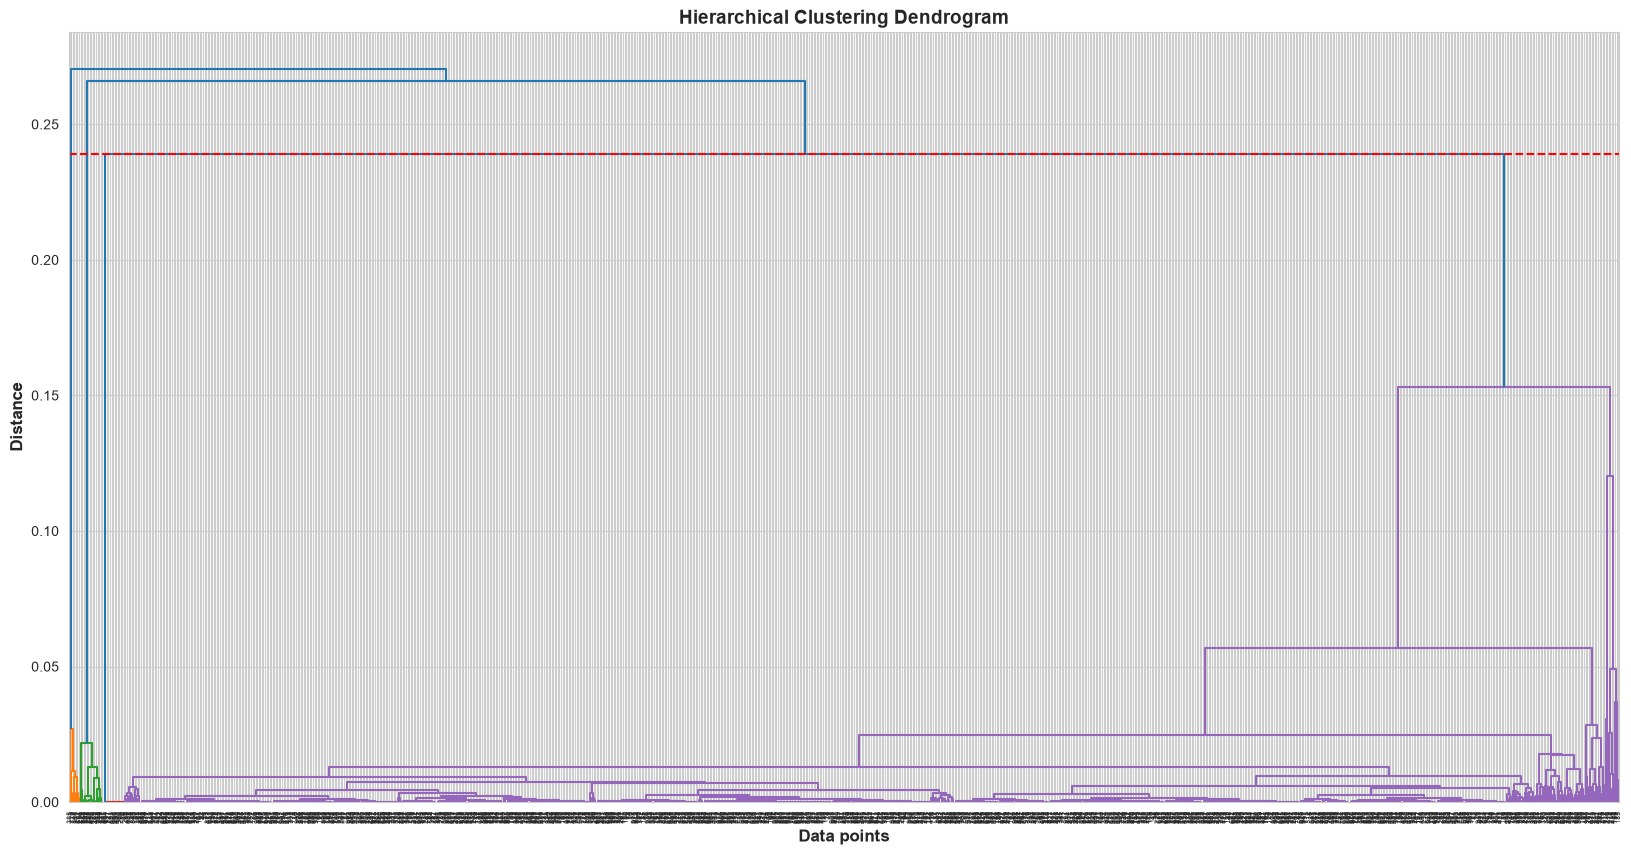

In [ ]:
# Fit the final hierarchical clustering model on the sampled distance matrix
results = pd.read_csv("unsupervisedbest_combination_results.csv")
unsupervisedbest_combination_results = results.sort_values(by='best_score', ascending=False).head(1)
best_k = unsupervisedbest_combination_results['best_k'].iloc[0]
subset = unsupervisedbest_combination_results['subset'].iloc[0]
subset = ast.literal_eval(subset)
final_cluster = AgglomerativeClustering(n_clusters=best_k, metric='precomputed', linkage='average')
dist = gower_matrix(X_sample[subset], features=subset)
sample_labels = final_cluster.fit_predict(dist)
X_sample['cluster'] = sample_labels

print('Sample cluster distribution:')
print(X_sample['cluster'].value_counts().sort_index())

# dendrogram 
condensed_dist = squareform(dist)
Z = linkage(condensed_dist, method='average')
plt.figure(figsize=(20, 10))

dendrogram(Z)
plt.axhline(y=Z[-(best_k-1), 2], color='r', linestyle='--')

plt.title("Hierarchical Clustering Dendrogram",fontsize=14, fontweight="bold")
plt.xlabel("Data points", fontweight="bold", fontsize=12)
plt.ylabel("Distance", fontweight="bold", fontsize=12)
plt.show()

### 4- Identify medoids and label main data set

In [ ]:
# Identify medoid rows for each cluster in the sample

medoid_indices = []
for cluster_id in sorted(X_sample['cluster'].unique()):
    idx = np.where(X_sample['cluster'] == cluster_id)[0]
    subdist = dist[np.ix_(idx, idx)]
    medoid_rel = idx[np.argmin(subdist.sum(axis=1))]
    medoid_indices.append(medoid_rel)

medoid_df = X_sample.iloc[medoid_indices].reset_index(drop=True)


def assign_cluster_by_medoids(full_df, medoids, categorical_features):
    numeric_features = [c for c in full_df.select_dtypes(include=[np.number]).columns.tolist()]
    # numeric_features = [c for c in full_df.select_dtypes(include=[np.number]).columns.tolist() if c not in categorical_features]
    cat_features = [c for c in categorical_features if c in full_df.columns]

  

    if len(numeric_features):
        X_num = full_df[numeric_features].astype(float).to_numpy() if len(numeric_features) else None
        M_num = medoids[numeric_features].astype(float).to_numpy() if len(numeric_features) else None
        ranges = X_num.max(axis=0) - X_num.min(axis=0)
        ranges[ranges == 0] = 1
        X_num_scaled = X_num / ranges
        M_num_scaled = M_num / ranges
        num_dists = pairwise_distances(X_num_scaled, M_num_scaled, metric='manhattan', n_jobs=-1) / len(numeric_features)
    else:
        num_dists = np.zeros((len(full_df), len(medoids)))

    if len(cat_features):
        cat_dists = np.zeros((len(full_df), len(medoids)), dtype=float)
        for col in cat_features:
            full_vals = full_df[col].astype(str).to_numpy()
            medoid_vals = medoids[col].astype(str).to_numpy()
            cat_dists += (full_vals[:, None] != medoid_vals[None, :]).astype(float)
        cat_dists /= len(cat_features)
    else:
        cat_dists = np.zeros((len(full_df), len(medoids)))

    if len(numeric_features) and len(cat_features):
        total = (num_dists * len(numeric_features) + cat_dists * len(cat_features)) / (
            len(numeric_features) + len(cat_features)
        )
    elif len(numeric_features):
        total = num_dists
    else:
        total = cat_dists

    return np.argmin(total, axis=1)

clustered_df = X.copy()
clustered_df['cluster'] = assign_cluster_by_medoids(X_cluster, medoid_df, categorical_features=cat_cols)
clustered_df['high_value_booking'] = y.values


print('Cluster distribution:')
print(clustered_df['cluster'].value_counts().sort_index())

Cluster distribution:
cluster
0    35957
1     2325
2     1583
3     4493
Name: count, dtype: int64


## 5 Profile clusters with core statistics



Cluster profile:
 cluster  size  high_value_rate  recommendation_rate  is_b2b_rate mode_city mode_hotel_accommodation  avg_discount  avg_hotel_rank  avg_hotel_stars  avg_lead_time  avg_stay_nights  avg_final_price  avg_children  avg_extra_bed  per_size  per_high_value  per_recommendation  per_is_b2b
       0 35957             8978                  156           14         1                    Hotel     12.953686       55.096504         3.228523       4.970548         2.088495       239.579350      0.833551       0.420864 81.060913       80.955816           21.081081    3.674541
       1  2325              717                    6          365         1                    Hotel      3.226133       42.259355         4.185806       7.824086         2.349677       423.999673      0.764731       0.430108  5.241445        6.465284            0.810811   95.800525
       2  1583              368                  555            1         1                    Hotel      2.124043       74.044220

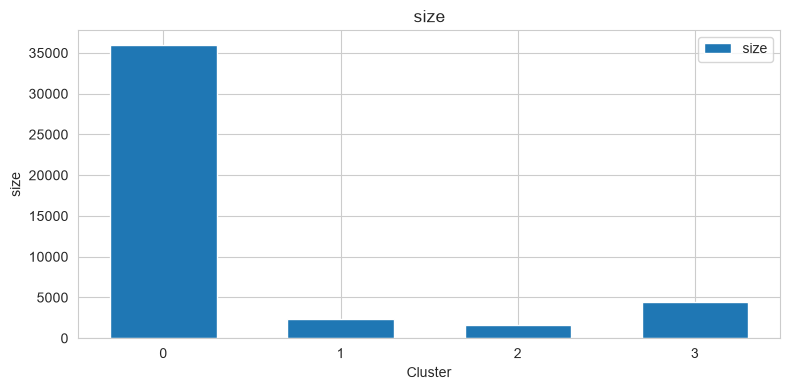

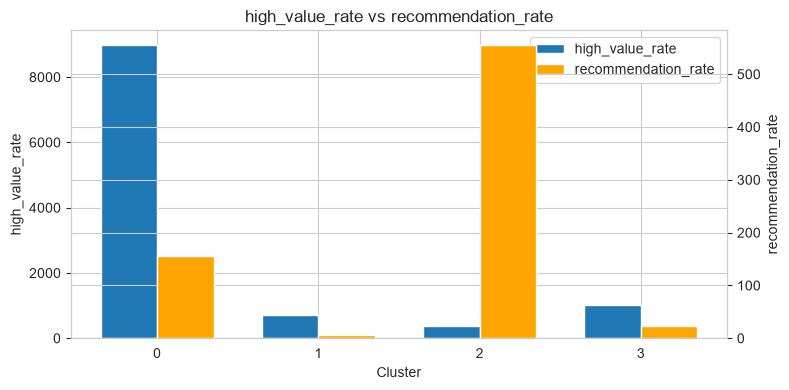

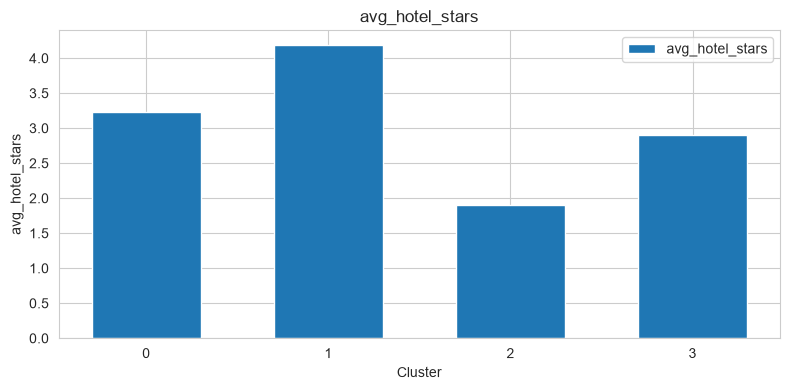

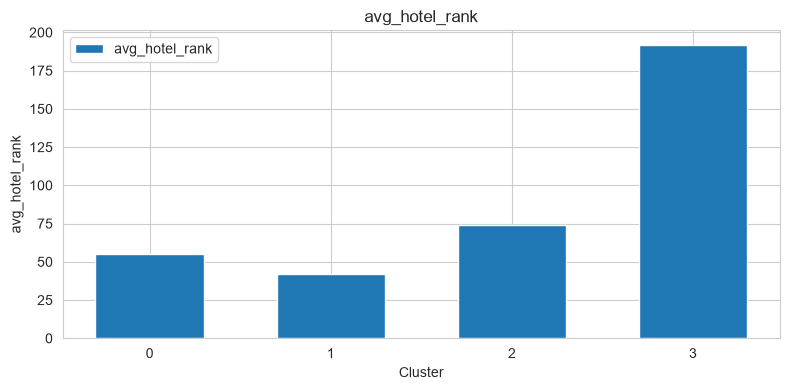

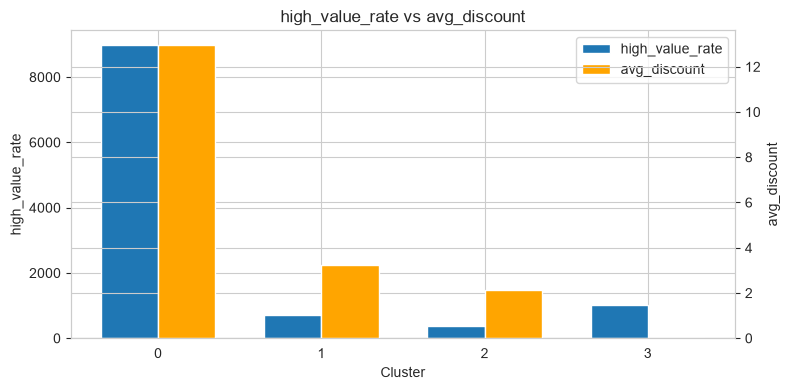

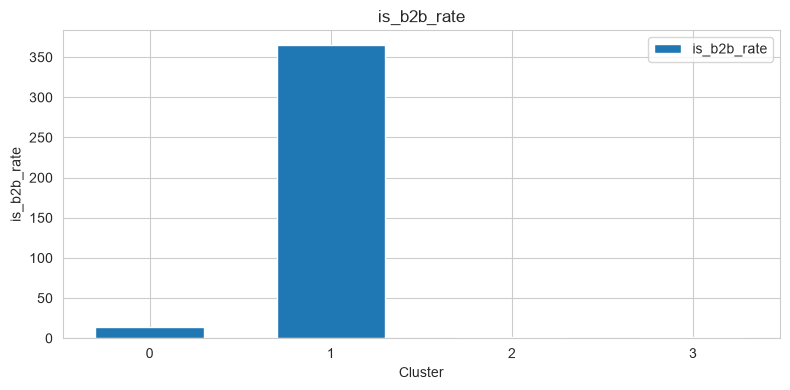

: 

In [ ]:
profile_aggs = {
    'size': ('cluster', 'size'),
    'high_value_rate': ('high_value_booking', 'sum'),
    'recommendation_rate': ('book_from_recommendation', 'sum'),
    'is_b2b_rate': ('is_b2b', 'sum'),
    'mode_city': ('city_id', lambda s: s.mode().iloc[0] if len(s.mode()) > 0 else np.nan),
    'mode_hotel_accommodation': ('hotel_accommodation', lambda s: s.mode().iloc[0] if len(s.mode()) > 0 else np.nan)
}
optional_stats = {
    'avg_discount': 'discount',
    'avg_hotel_rank': 'hotel_rank',
    'avg_hotel_stars': 'hotel_stars',
    'avg_lead_time': 'lead_time_days',
    'avg_stay_nights': 'stay_nights',
    'avg_final_price': 'final_price',
    'avg_children': 'sum_room_children',
    'avg_extra_bed': 'sum_room_extra_bed',
}
for stat_name, col_name in optional_stats.items():
    if col_name in clustered_df.columns:
        profile_aggs[stat_name] = (col_name, 'mean')

cluster_profile = clustered_df.groupby('cluster').agg(**profile_aggs).reset_index()

total_size = cluster_profile['size'].sum()
total_high_value = cluster_profile['high_value_rate'].sum()
total_recommendations = cluster_profile['recommendation_rate'].sum()
total_is_b2b = cluster_profile['is_b2b_rate'].sum()



cluster_profile['per_size'] = (cluster_profile['size'] / total_size * 100)
cluster_profile['per_high_value'] = (cluster_profile['high_value_rate'] / total_high_value * 100)
cluster_profile['per_recommendation'] = (cluster_profile['recommendation_rate'] / total_recommendations * 100)
cluster_profile['per_is_b2b'] = (cluster_profile['is_b2b_rate'] / total_is_b2b * 100)


print('\nCluster profile:')
print(cluster_profile.to_string(index=False))

# # Visualize the most important cluster differences
plot_cols = [['size'],['high_value_rate','recommendation_rate'],['avg_hotel_stars'],['avg_hotel_rank'],['high_value_rate','avg_discount'],['is_b2b_rate']]


for cols in plot_cols:

    x = np.arange(len(cluster_profile))
    labels = cluster_profile['cluster'].astype(str)

    fig, ax1 = plt.subplots(figsize=(8, 4))

    if len(cols) == 1:
        col = cols[0]

        ax1.bar(x, cluster_profile[col], width=0.6, label=col)
        ax1.set_ylabel(col)
        ax1.legend()

    elif len(cols) == 2:
        col1, col2 = cols
        width = 0.35

        # Left axis bars
        bars1 = ax1.bar(
            x - width/2,
            cluster_profile[col1],
            width=width,
            label=col1
        )
        ax1.set_ylabel(col1)

        # Right axis bars
        ax2 = ax1.twinx()

        bars2 = ax2.bar(
            x + width/2,
            cluster_profile[col2],
            width=width,
            label=col2,
            color='orange'
        )
        ax2.set_ylabel(col2)

        # Combined legend
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1 + h2, l1 + l2)

    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.set_xlabel('Cluster')
    ax1.set_title(' vs '.join(cols))

    plt.tight_layout()
    plt.show()

